# Front-athlete detection and background isolation

This notebook finds the athlete whose feet are closest to the center of the competition ground, keeps that identity across the video, removes the background with an instance-segmentation mask, and produces a centered crop for later pose estimation and scoring.

The initial athlete is selected using the bottom of each YOLO26 person mask (an estimate of where the person touches the floor), rather than the center of the person's bounding box. This avoids selecting judges or people in the audience whose upper bodies happen to be near the image center.

## Environment

Activate the project environment before launching Jupyter:

```bash
cd ~/Desktop/poomsae-scoring-system
source .venv/bin/activate
python -m pip install -r requirements.txt
jupyter lab
```

The first model-loading run downloads the official `yolo26n-seg.pt` weights.

In [24]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1" 


In [25]:
import torch
print(torch.__version__)


2.6.0+cu124


In [21]:
import torch

torch.cuda.is_available()

# torch.cuda.device_count()
# torch.cuda.current_device()
# torch.cuda.get_device_name(0)

True

In [22]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from poomsae_scoring.device import describe_inference_device, resolve_inference_device
from poomsae_scoring.preprocessing import (
    box_bottom_contact_points,
    box_iou,
    interpolate_box_gaps,
    isolate_person,
    letterbox_frame,
    padded_crop,
    select_tracking_candidate,
)

ATHLETE_ID = "WP2"
CAMERA_ANGLE = 35  # Use 0, 35/45, or 135/145.
# The files in this dataset use 45 and 135; accept 35 and 145 as aliases.
DATASET_ANGLE = {35: 45, 145: 135}.get(CAMERA_ANGLE, CAMERA_ANGLE)
VIDEO_PATH = PROJECT_ROOT / f"data/raw/cut-women-{DATASET_ANGLE}/{ATHLETE_ID}-{DATASET_ANGLE}.MP4"
OUTPUT_DIR = PROJECT_ROOT / f"data/processed/center_athlete/{ATHLETE_ID}-{CAMERA_ANGLE}"
MODEL_NAME = "yolo26n-seg.pt"
CONFIDENCE = 0.25
RECOVERY_CONFIDENCE = 0.10
RECOVERY_IMAGE_SIZE = 1280
MAX_TRAJECTORY_GAP = 20
OUTPUT_SIZE = 640
INFERENCE_DEVICE = "cuda:0"  # Use "auto" only if CPU fallback is acceptable.
DEVICE = resolve_inference_device(INFERENCE_DEVICE)
print(describe_inference_device(DEVICE))

# The next section detects the yellow mat boundary directly from the selected
# camera view, then chooses the person whose feet are nearest its center.

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert VIDEO_PATH.exists(), f"Video not found: {VIDEO_PATH}"
VIDEO_PATH

Inference device: cuda:0 (NVIDIA GeForce RTX 3060 Laptop GPU)


PosixPath('/home/nazi/Desktop/poomsae-scoring-system/data/raw/cut-women-45/WP2-45.MP4')

In [ ]:
capture = cv2.VideoCapture(str(VIDEO_PATH))
fps = capture.get(cv2.CAP_PROP_FPS)
frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps
capture.release()

print(f"Frames: {frame_count}")
print(f"FPS: {fps:.2f}")
print(f"Resolution: {frame_width}x{frame_height}")
print(f"Duration: {duration:.2f} seconds")

Frames: 2336
FPS: 50.00
Resolution: 1920x1080
Duration: 46.72 seconds


## Inspect a representative frame

The yellow octagonal border is detected first and converted into a mat polygon. The red cross is the center of that detected polygon. For every detected person, the circle at the bottom of the mask estimates the person's floor-contact point. Only people whose contact point is inside the mat are eligible; the green person is the eligible person closest to the red cross.

Set `CAMERA_ANGLE` to `0`, `35`/`45`, or `135`/`145` and rerun from the setup cell. `MANUAL_CANDIDATE_INDEX` remains available only as a fallback after checking this preview.

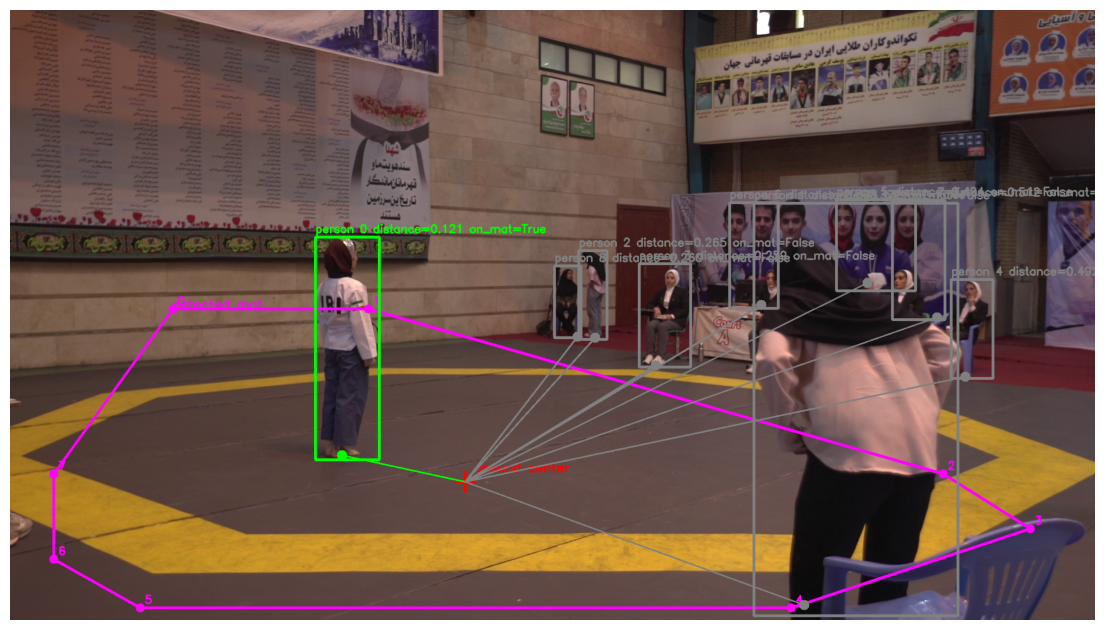

Mat detection: camera-calibrated octagon after occlusion check
Octagon corners: 8
Selected candidate: 0


In [12]:
model = YOLO(MODEL_NAME)
reference_frame_number = round(frame_count * 0.05)
capture = cv2.VideoCapture(str(VIDEO_PATH))
capture.set(cv2.CAP_PROP_POS_FRAMES, reference_frame_number)
success, reference_frame = capture.read()
capture.release()
assert success, "Could not read the reference frame."


def detect_competition_mat(frame, camera_angle):
    """Fit an eight-corner polygon to the yellow octagonal mat border."""
    image_height, image_width = frame.shape[:2]
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    yellow_mask = cv2.inRange(
        hsv,
        np.array([15, 80, 70], dtype=np.uint8),
        np.array([42, 255, 255], dtype=np.uint8),
    )
    yellow_mask[: round(0.35 * image_height)] = 0

    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    yellow_mask = cv2.morphologyEx(
        yellow_mask, cv2.MORPH_CLOSE, close_kernel, iterations=2
    )
    yellow_mask = cv2.morphologyEx(
        yellow_mask, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8)
    )

    contours, _ = cv2.findContours(
        yellow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    minimum_component_area = 0.001 * image_width * image_height
    mat_components = []
    for contour in contours:
        _, top, _, height = cv2.boundingRect(contour)
        if (
            cv2.contourArea(contour) >= minimum_component_area
            and top + height >= 0.45 * image_height
        ):
            mat_components.append(contour)

    if not mat_components:
        raise RuntimeError(
            "Could not detect the yellow competition-mat border in the reference frame."
        )

    outer_hull = cv2.convexHull(np.concatenate(mat_components, axis=0))
    perimeter = cv2.arcLength(outer_hull, True)
    octagon_candidates = []
    for epsilon_ratio in np.linspace(0.0005, 0.03, 296):
        candidate = cv2.approxPolyDP(
            outer_hull, float(epsilon_ratio * perimeter), True
        ).reshape(-1, 2)
        if len(candidate) == 8:
            octagon_candidates.append((epsilon_ratio, candidate))

    frame_diagonal = np.hypot(image_width, image_height)

    def is_valid_octagon(polygon):
        polygon = np.asarray(polygon, dtype=np.float32)
        side_lengths = np.linalg.norm(polygon - np.roll(polygon, 1, axis=0), axis=1)
        return (
            len(polygon) == 8
            and cv2.isContourConvex(polygon.reshape(-1, 1, 2))
            and side_lengths.min() >= 0.04 * frame_diagonal
            and cv2.contourArea(polygon) >= 0.10 * image_width * image_height
        )

    automatic_octagons = [
        (epsilon_ratio, candidate)
        for epsilon_ratio, candidate in octagon_candidates
        if is_valid_octagon(candidate)
    ]

    if automatic_octagons:
        _, outer_octagon = max(automatic_octagons, key=lambda item: item[0])
        outer_moments = cv2.moments(outer_octagon)
        outer_center = np.array(
            [
                outer_moments["m10"] / outer_moments["m00"],
                outer_moments["m01"] / outer_moments["m00"],
            ],
            dtype=float,
        )
        mat_polygon = outer_center + 0.90 * (outer_octagon - outer_center)
        detection_source = "automatic yellow-border octagon"
    else:
        calibrated_octagons = {
            0: np.array(
                [
                    (0.60, 0.48), (0.95, 0.61), (0.95, 0.78), (0.90, 0.90),
                    (0.71, 0.97), (0.25, 0.92), (0.05, 0.75), (0.05, 0.63),
                ],
                dtype=float,
            ),
            45: np.array(
                [
                    (0.15, 0.49), (0.33, 0.49), (0.86, 0.76), (0.94, 0.85),
                    (0.72, 0.98), (0.12, 0.98), (0.04, 0.90), (0.04, 0.76),
                ],
                dtype=float,
            ),
            135: np.array(
                [
                    (0.09, 0.45), (0.70, 0.49), (0.86, 0.53), (0.99, 0.61),
                    (0.84, 0.70), (0.25, 0.72), (0.10, 0.63), (0.05, 0.54),
                ],
                dtype=float,
            ),
        }
        if camera_angle not in calibrated_octagons:
            raise ValueError(f"No mat calibration exists for camera angle {camera_angle}.")
        mat_polygon = calibrated_octagons[camera_angle] * np.array(
            [image_width, image_height]
        )
        detection_source = "camera-calibrated octagon after occlusion check"

    mat_polygon = np.rint(mat_polygon).astype(np.int32)
    if not is_valid_octagon(mat_polygon):
        raise RuntimeError("Mat detection did not produce a valid eight-sided octagon.")
    moments = cv2.moments(mat_polygon)
    center = np.array(
        [moments["m10"] / moments["m00"], moments["m01"] / moments["m00"]],
        dtype=float,
    )
    return mat_polygon, center, yellow_mask, detection_source


mat_polygon, ground_center, mat_detection_mask, mat_detection_source = (
    detect_competition_mat(reference_frame, DATASET_ANGLE)
)
assert len(mat_polygon) == 8, "The competition mat must be an octagon."

reference_result = model.predict(
    reference_frame,
    device=DEVICE,
    classes=[0],
    conf=CONFIDENCE,
    retina_masks=True,
    verbose=False,
)[0]
assert reference_result.boxes is not None and len(reference_result.boxes) > 0, (
    "No people were detected in the reference frame."
)
assert reference_result.masks is not None, "YOLO did not return segmentation masks."

reference_boxes = reference_result.boxes.xyxy.cpu().numpy()
reference_masks = reference_result.masks.data.cpu().numpy()


def mask_ground_contact(mask, box, image_width, image_height):
    """Estimate the point between the person's feet from the mask bottom."""
    if mask.shape != (image_height, image_width):
        mask = cv2.resize(
            mask.astype(np.float32),
            (image_width, image_height),
            interpolation=cv2.INTER_NEAREST,
        )
    y_coordinates, x_coordinates = np.nonzero(mask > 0.5)
    if y_coordinates.size == 0:
        x1, _, x2, y2 = box
        return np.array([(x1 + x2) / 2, y2], dtype=float)

    # Use a thin band at the mask bottom. Its median x is stable when one foot
    # is lifted and is less sensitive to single stray mask pixels.
    person_height = max(float(box[3] - box[1]), 1.0)
    bottom_y = float(np.percentile(y_coordinates, 99.5))
    bottom_band = y_coordinates >= bottom_y - max(3.0, 0.03 * person_height)
    contact_x = float(np.median(x_coordinates[bottom_band]))
    contact_y = float(np.median(y_coordinates[bottom_band]))
    return np.array([contact_x, contact_y], dtype=float)


ground_contacts = np.array(
    [
        mask_ground_contact(mask, box, frame_width, frame_height)
        for mask, box in zip(reference_masks, reference_boxes)
    ]
)
# Normalize x and y before measuring distance so the result is independent of
# video resolution and aspect ratio. Smaller distance is better.
ground_distances = np.linalg.norm(
    (ground_contacts - ground_center) / np.array([frame_width, frame_height]),
    axis=1,
)
contacts_on_mat = np.array(
    [
        cv2.pointPolygonTest(
            mat_polygon.astype(np.float32), tuple(contact.astype(float)), False
        )
        >= 0
        for contact in ground_contacts
    ],
    dtype=bool,
)
if not contacts_on_mat.any():
    raise RuntimeError(
        "People were detected, but no person's foot contact is inside the detected mat."
    )
eligible_distances = np.where(contacts_on_mat, ground_distances, np.inf)
automatic_index = int(np.argmin(eligible_distances))

MANUAL_CANDIDATE_INDEX = None
selected_index = automatic_index if MANUAL_CANDIDATE_INDEX is None else MANUAL_CANDIDATE_INDEX
reference_target_box = reference_boxes[selected_index].copy()

preview = reference_frame.copy()
center_x, center_y = np.rint(ground_center).astype(int)
cv2.drawMarker(
    preview,
    (center_x, center_y),
    (0, 0, 255),
    cv2.MARKER_CROSS,
    36,
    4,
)
cv2.putText(
    preview,
    "ground center",
    (center_x + 18, center_y - 18),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.75,
    (0, 0, 255),
    2,
)
cv2.polylines(preview, [mat_polygon], True, (255, 0, 255), 3)
for corner_index, corner in enumerate(mat_polygon):
    corner_point = tuple(np.asarray(corner, dtype=int))
    cv2.circle(preview, corner_point, 8, (255, 0, 255), -1)
    cv2.putText(
        preview,
        str(corner_index),
        (corner_point[0] + 8, corner_point[1] - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (255, 0, 255),
        2,
    )
cv2.putText(
    preview,
    "detected mat",
    tuple(mat_polygon[0]),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.75,
    (255, 0, 255),
    2,
)

for index, (box, contact, distance, is_on_mat) in enumerate(
    zip(reference_boxes, ground_contacts, ground_distances, contacts_on_mat)
):
    x1, y1, x2, y2 = box.astype(int)
    contact_point = tuple(np.rint(contact).astype(int))
    color = (0, 255, 0) if index == selected_index else (0, 165, 255)
    if not is_on_mat:
        color = (128, 128, 128)
    cv2.rectangle(preview, (x1, y1), (x2, y2), color, 3)
    cv2.circle(preview, contact_point, 9, color, -1)
    cv2.line(preview, contact_point, (center_x, center_y), color, 2)
    cv2.putText(
        preview,
        f"person {index} distance={distance:.3f} on_mat={is_on_mat}",
        (x1, max(25, y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        color,
        2,
    )

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
print(f"Mat detection: {mat_detection_source}")
print(f"Octagon corners: {len(mat_polygon)}")
print(f"Selected candidate: {selected_index}")

## Track and isolate the center-ground athlete

This section uses two passes so the athlete selected in the reference frame is also identified in the earlier frames:

1. ByteTrack records all person boxes and IDs for the complete video. Starting at the reference frame, the selected athlete's trajectory is followed both backward and forward.
2. YOLO26 segmentation runs again and selects the mask that matches the saved target box in each frame.

A missing or implausible match produces a black frame instead of silently switching to another person.

Outputs:
- `foreground.mp4`: full frame with the background blacked out.
- `athlete_crop.mp4`: isolated athlete centered on a 640×640 canvas.
- `tracking.csv`: selected track ID, box, and confidence for each frame.

In [ ]:
foreground_path = OUTPUT_DIR / "foreground.mp4"
crop_path = OUTPUT_DIR / "athlete_crop.mp4"
tracking_path = OUTPUT_DIR / "tracking.csv"
codec = cv2.VideoWriter_fourcc(*"mp4v")


def plausible_same_person(
    candidate_box,
    previous_box,
    max_center_step=0.08,  
    min_area_ratio=0.35,
    max_area_ratio=4.00,   
):
    """Reject a geometric recovery that is likely to be another person."""
    candidate_box = np.asarray(candidate_box, dtype=float)
    previous_box = np.asarray(previous_box, dtype=float)
    
    candidate_center = np.array(
        [(candidate_box[0] + candidate_box[2]) / 2, candidate_box[3]] 
    )
    previous_center = np.array(
        [(previous_box[0] + previous_box[2]) / 2, previous_box[3]]
    )
    
    normalized_step = np.linalg.norm(
        (candidate_center - previous_center) / np.array([frame_width, frame_height])
    )
    candidate_area = max(
        1.0, (candidate_box[2] - candidate_box[0]) * (candidate_box[3] - candidate_box[1])
    )
    previous_area = max(
        1.0, (previous_box[2] - previous_box[0]) * (previous_box[3] - previous_box[1])
    )
    area_ratio = candidate_area / previous_area
    
    return (
        box_iou(candidate_box, previous_box) >= 0.05
        or (
            normalized_step <= max_center_step
            and min_area_ratio <= area_ratio <= max_area_ratio
        )
    )



def point_on_mat(point):
    return cv2.pointPolygonTest(
        mat_polygon.astype(np.float32), tuple(np.asarray(point, dtype=float)), False
    ) >= 0


def box_feet_on_mat(box):
    """Accept either possible stance foot when a kick widens the box."""
    return any(point_on_mat(point) for point in box_bottom_contact_points(box))


def mask_feet_on_mat(mask, box):
    """Use the lowest mask pixels to locate the actual grounded foot."""
    contact = mask_ground_contact(mask, box, frame_width, frame_height)
    return point_on_mat(contact)


# PASS 1: run ByteTrack through the entire video and save only lightweight
# boxes/IDs. A separate model instance ensures a fresh tracker state.
tracking_model = YOLO(MODEL_NAME)
capture = cv2.VideoCapture(str(VIDEO_PATH))
detections_by_frame = []

for frame_index in tqdm(range(frame_count), desc="Pass 1/2: tracking all people"):
    success, frame = capture.read()
    if not success:
        break
    result = tracking_model.track(
        frame,
        device=DEVICE,
        persist=True,
        tracker="bytetrack.yaml",
        classes=[0],
        conf=RECOVERY_CONFIDENCE,
        verbose=False,
    )[0]
    if result.boxes is None or len(result.boxes) == 0:
        detections_by_frame.append(
            {"boxes": np.empty((0, 4)), "ids": np.empty(0, dtype=int)}
        )
        continue
    boxes = result.boxes.xyxy.cpu().numpy()
    track_ids = (
        result.boxes.id.int().cpu().numpy()
        if result.boxes.id is not None
        else np.full(len(boxes), -1, dtype=int)
    )
    detections_by_frame.append({"boxes": boxes, "ids": track_ids})

capture.release()
tracked_frame_count = len(detections_by_frame)
assert reference_frame_number < tracked_frame_count, "Reference frame was not tracked."

# Anchor the trajectory to the exact person selected in the previous cell.
anchor_detections = detections_by_frame[reference_frame_number]
assert len(anchor_detections["boxes"]) > 0, (
    "No tracked people exist at the reference frame. Try another reference frame."
)
anchor_index = select_tracking_candidate(
    anchor_detections["boxes"],
    reference_target_box,
    frame_width,
    frame_height,
)
anchor_box = anchor_detections["boxes"][anchor_index].copy()
anchor_id = int(anchor_detections["ids"][anchor_index])
target_boxes = [None] * tracked_frame_count
target_ids = [None] * tracked_frame_count
target_boxes[reference_frame_number] = anchor_box
target_ids[reference_frame_number] = anchor_id if anchor_id >= 0 else None


def follow_selected_athlete(frame_indices, initial_box, initial_id):
    """Follow one identity in either time direction from the anchor frame."""
    previous_box = initial_box.copy()
    current_id = initial_id
    missed_frames = 0
    for frame_index in frame_indices:
        detections = detections_by_frame[frame_index]
        boxes = detections["boxes"]
        ids = detections["ids"]
        if len(boxes) == 0:
            missed_frames += 1
            continue

        allowed_center_step = 0.045 * min(missed_frames + 1, 4)
        selected = None
        if current_id is not None and current_id >= 0:
            id_matches = np.flatnonzero(ids == current_id)
            if id_matches.size:
                id_candidate = int(id_matches[0])
                if box_feet_on_mat(boxes[id_candidate]) and plausible_same_person(
                    boxes[id_candidate], previous_box, max_center_step=allowed_center_step
                ):
                    selected = id_candidate

        if selected is None:
            candidate = select_tracking_candidate(
                boxes, previous_box, frame_width, frame_height
            )
            if not box_feet_on_mat(boxes[candidate]) or not plausible_same_person(
                boxes[candidate], previous_box, max_center_step=allowed_center_step
            ):
                missed_frames += 1
                continue
            selected = candidate
            if ids[selected] >= 0:
                current_id = int(ids[selected])

        previous_box = boxes[selected].copy()
        missed_frames = 0
        target_boxes[frame_index] = previous_box
        target_ids[frame_index] = int(ids[selected]) if ids[selected] >= 0 else current_id


follow_selected_athlete(
    range(reference_frame_number + 1, tracked_frame_count), anchor_box, target_ids[reference_frame_number]
)
follow_selected_athlete(
    range(reference_frame_number - 1, -1, -1), anchor_box, target_ids[reference_frame_number]
)

# Preserve which boxes ByteTrack observed, then bridge only short gaps. The
# interpolated box is used as a search region; pass 2 still requires a real
# segmentation mask, so interpolation cannot create a false silhouette.
trajectory_observed = [box is not None for box in target_boxes]
target_boxes = interpolate_box_gaps(target_boxes, MAX_TRAJECTORY_GAP)

# PASS 2: rerun instance segmentation and take only the mask matching the
# selected athlete's saved trajectory.
foreground_writer = cv2.VideoWriter(
    str(foreground_path), codec, fps, (frame_width, frame_height)
)
crop_writer = cv2.VideoWriter(
    str(crop_path), codec, fps, (OUTPUT_SIZE, OUTPUT_SIZE)
)
capture = cv2.VideoCapture(str(VIDEO_PATH))
rows = []


def find_athlete_segmentation(frame, expected_box):
    """Retry missed dynamic poses at higher resolution and lower confidence."""
    attempts = (
        (OUTPUT_SIZE, CONFIDENCE),
        (RECOVERY_IMAGE_SIZE, RECOVERY_CONFIDENCE),
    )
    for image_size, confidence in attempts:
        result = model.predict(
            frame,
            device=DEVICE,
            classes=[0],
            conf=confidence,
            imgsz=image_size,
            retina_masks=True,
            verbose=False,
        )[0]
        if result.boxes is None or len(result.boxes) == 0 or result.masks is None:
            continue
        boxes = result.boxes.xyxy.cpu().numpy()
        masks = result.masks.data.cpu().numpy()
        candidate = select_tracking_candidate(
            boxes, expected_box, frame_width, frame_height
        )
        if mask_feet_on_mat(masks[candidate], boxes[candidate]) and plausible_same_person(
            boxes[candidate], expected_box, max_center_step=0.045
        ):
            return result, candidate
    return None, None


for frame_index in tqdm(range(tracked_frame_count), desc="Pass 2/2: isolating selected athlete"):
    success, frame = capture.read()
    if not success:
        break
    expected_box = target_boxes[frame_index]
    result, selected = (
        find_athlete_segmentation(frame, expected_box)
        if expected_box is not None
        else (None, None)
    )

    if selected is None:
        foreground_writer.write(np.zeros_like(frame))
        crop_writer.write(np.zeros((OUTPUT_SIZE, OUTPUT_SIZE, 3), dtype=np.uint8))
        rows.append(
            [
                frame_index,
                target_ids[frame_index] if target_ids[frame_index] is not None else "",
                "",
                "",
                "",
                "",
                "",
                "missing",
            ]
        )
        continue

    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()
    masks = result.masks.data.cpu().numpy()
    selected_box = boxes[selected]
    foreground = isolate_person(frame, masks[selected])
    athlete_crop = padded_crop(foreground, selected_box, padding_ratio=0.25)
    normalized_crop = letterbox_frame(athlete_crop, OUTPUT_SIZE, OUTPUT_SIZE)
    foreground_writer.write(foreground)
    crop_writer.write(normalized_crop)

    x1, y1, x2, y2 = selected_box.tolist()
    rows.append(
        [
            frame_index,
            target_ids[frame_index] if target_ids[frame_index] is not None else "",
            float(confidences[selected]),
            x1,
            y1,
            x2,
            y2,
            "tracked" if trajectory_observed[frame_index] else "recovered",
        ]
    )

capture.release()
foreground_writer.release()
crop_writer.release()

with tracking_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["frame", "track_id", "confidence", "x1", "y1", "x2", "y2", "status"])
    writer.writerows(rows)

isolated_count = sum(row[-1] != "missing" for row in rows)
recovered_count = sum(row[-1] == "recovered" for row in rows)
print(f"Isolated the selected athlete in {isolated_count}/{len(rows)} frames")
print(f"Recovered {recovered_count} frames across short tracking gaps")
print(f"Foreground video: {foreground_path}")
print(f"Athlete crop: {crop_path}")
print(f"Tracking data: {tracking_path}")


Pass 2/2: isolating selected athlete: 100%|██████████| 2334/2334 [02:08<00:00, 18.18it/s]


Isolated the selected athlete in 2154/2334 frames
Recovered 8 frames across short tracking gaps
Foreground video: /home/nazi/Desktop/poomsae-scoring-system/data/processed/center_athlete/WP2-35/foreground.mp4
Athlete crop: /home/nazi/Desktop/poomsae-scoring-system/data/processed/center_athlete/WP2-35/athlete_crop.mp4
Tracking data: /home/nazi/Desktop/poomsae-scoring-system/data/processed/center_athlete/WP2-35/tracking.csv


## Preview the processed result

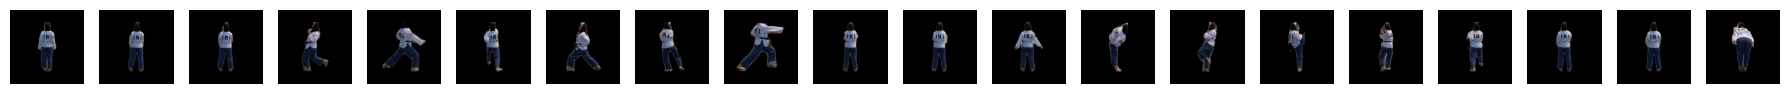

In [69]:
processed_capture = cv2.VideoCapture(str(crop_path))
preview_frames = []
for fraction in (0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.50, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99):
    processed_capture.set(cv2.CAP_PROP_POS_FRAMES, round(frame_count * fraction))
    success, frame = processed_capture.read()
    if success:
        preview_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
processed_capture.release()

figure, axes = plt.subplots(1, len(preview_frames), figsize=(18, 5))
for axis, frame in zip(np.atleast_1d(axes), preview_frames):
    axis.imshow(frame)
    axis.axis("off")
plt.tight_layout()
plt.show()

## Estimate the athlete's 2D pose

Pose estimation is the correct next step after athlete isolation. The scoring notes identify several criteria that can be approximated from body landmarks: knee extension and flexion, stance depth and width, hand and foot endpoints, deviation from the body midline, trunk rotation, and visible loss of balance.

This stage runs a pose model on `athlete_crop.mp4` and creates:
- `pose_keypoints.csv`: frame time plus the x, y, and confidence of all 17 COCO body keypoints.
- `pose_overlay.mp4`: the normalized athlete crop with the detected skeleton drawn on it.

The first pose-model run downloads the official `yolo26n-pose.pt` weights. Keep the confidence values: low-confidence or hidden joints must not be treated as real scoring errors.

In [ ]:
POSE_MODEL_NAME = "yolo26n-pose.pt"
POSE_CONFIDENCE = 0.25
KEYPOINT_CONFIDENCE = 0.25

KEYPOINT_NAMES = (
    "left_eye",
    "right_eye",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
)

SKELETON_EDGES = (
    (5, 7),
    (7, 9),
    (5, 11),
    (6, 12),
    (11, 12),
    (11, 13),
    (13, 15),
    (12, 14),
    (14, 16),
)

pose_model = YOLO(POSE_MODEL_NAME)

In [9]:
pose_csv_path = OUTPUT_DIR / "pose_keypoints.csv"
pose_overlay_path = OUTPUT_DIR / "pose_overlay.mp4"
pose_capture = cv2.VideoCapture(str(crop_path))
pose_frame_count = int(pose_capture.get(cv2.CAP_PROP_FRAME_COUNT))
pose_writer = cv2.VideoWriter(
    str(pose_overlay_path), codec, fps, (OUTPUT_SIZE, OUTPUT_SIZE)
)

pose_rows = []
pose_confidence_history = []
detected_pose_frames = 0

for frame_index in tqdm(range(pose_frame_count), desc="Estimating 2D pose"):
    success, frame = pose_capture.read()
    if not success:
        break

    result = pose_model.predict(
        frame,
        device=DEVICE,
        conf=POSE_CONFIDENCE,
        verbose=False,
    )[0]
    annotated_frame = frame.copy()
    timestamp_seconds = frame_index / fps

    if result.keypoints is None or len(result.keypoints) == 0:
        empty_keypoints = [""] * (len(KEYPOINT_NAMES) * 3)
        pose_rows.append([frame_index, timestamp_seconds, "missing", *empty_keypoints])
        pose_confidence_history.append(np.full(len(KEYPOINT_NAMES), np.nan))
        pose_writer.write(annotated_frame)
        continue

    pose_index = int(np.argmax(result.boxes.conf.cpu().numpy()))
    keypoint_data = result.keypoints.data[pose_index].cpu().numpy()
    coordinates = keypoint_data[:, :2]
    confidences = keypoint_data[:, 2]
    detected_pose_frames += 1
    pose_confidence_history.append(confidences)

    flattened_keypoints = []
    for (x_coordinate, y_coordinate), confidence in zip(coordinates, confidences):
        flattened_keypoints.extend(
            [float(x_coordinate), float(y_coordinate), float(confidence)]
        )
    pose_rows.append(
        [frame_index, timestamp_seconds, "detected", *flattened_keypoints]
    )

    for start_index, end_index in SKELETON_EDGES:
        if min(confidences[start_index], confidences[end_index]) < KEYPOINT_CONFIDENCE:
            continue
        start_point = tuple(np.rint(coordinates[start_index]).astype(int))
        end_point = tuple(np.rint(coordinates[end_index]).astype(int))
        cv2.line(annotated_frame, start_point, end_point, (0, 220, 255), 3)

    for (x_coordinate, y_coordinate), confidence in zip(coordinates, confidences):
        if confidence < KEYPOINT_CONFIDENCE:
            continue
        center = tuple(np.rint([x_coordinate, y_coordinate]).astype(int))
        cv2.circle(annotated_frame, center, 5, (0, 255, 0), -1)

    pose_writer.write(annotated_frame)

pose_capture.release()
pose_writer.release()

pose_header = ["frame", "timestamp_seconds", "status"]
for keypoint_name in KEYPOINT_NAMES:
    pose_header.extend(
        [f"{keypoint_name}_x", f"{keypoint_name}_y", f"{keypoint_name}_confidence"]
    )

with pose_csv_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(pose_header)
    writer.writerows(pose_rows)

pose_coverage = detected_pose_frames / max(len(pose_rows), 1)
print(f"Pose keypoints: {pose_csv_path}")
print(f"Pose overlay: {pose_overlay_path}")
print(f"Pose detected in {pose_coverage:.1%} of processed frames")

Estimating 2D pose:   0%|          | 0/2614 [00:00<?, ?it/s]

Estimating 2D pose: 100%|██████████| 2614/2614 [00:29<00:00, 87.40it/s]


Pose keypoints: /home/nazi/Desktop/poomsae-scoring-system/data/processed/front_athlete/pose_keypoints.csv
Pose overlay: /home/nazi/Desktop/poomsae-scoring-system/data/processed/front_athlete/pose_overlay.mp4
Pose detected in 95.8% of processed frames


# Media Pipe

In [ ]:
import cv2
import csv
import numpy as np
import mediapipe as mp
from tqdm import tqdm

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

KEYPOINT_NAMES = [landmark.name for landmark in mp_pose.PoseLandmark]

pose_csv_path = OUTPUT_DIR / "pose_keypoints.csv"
pose_overlay_path = OUTPUT_DIR / "pose_overlay.mp4"
pose_capture = cv2.VideoCapture(str(crop_path))
pose_frame_count = int(pose_capture.get(cv2.CAP_PROP_FRAME_COUNT))

pose_writer = cv2.VideoWriter(
    str(pose_overlay_path), codec, fps, (OUTPUT_SIZE, OUTPUT_SIZE)
)

pose_rows = []
pose_confidence_history = []
detected_pose_frames = 0

with mp_pose.Pose(
    static_image_mode=False,
    model_complexity=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as pose:

    for frame_index in tqdm(range(pose_frame_count), desc="Estimating 2D pose (MediaPipe)"):
        success, frame = pose_capture.read()
        if not success:
            break

        if frame.shape[0] != OUTPUT_SIZE or frame.shape[1] != OUTPUT_SIZE:
            frame = cv2.resize(frame, (OUTPUT_SIZE, OUTPUT_SIZE))

        annotated_frame = frame.copy()
        timestamp_seconds = frame_index / fps

        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = pose.process(image_rgb)

        if not result.pose_landmarks:
            empty_keypoints = [""] * (len(KEYPOINT_NAMES) * 3)
            pose_rows.append([frame_index, timestamp_seconds, "missing", *empty_keypoints])
            pose_confidence_history.append(np.full(len(KEYPOINT_NAMES), np.nan))
            pose_writer.write(annotated_frame)
            continue

        detected_pose_frames += 1
        flattened_keypoints = []
        confidences = []

        for landmark in result.pose_landmarks.landmark:
            x_pixel = landmark.x * OUTPUT_SIZE
            y_pixel = landmark.y * OUTPUT_SIZE
            confidence = landmark.visibility
            
            flattened_keypoints.extend([float(x_pixel), float(y_pixel), float(confidence)])
            confidences.append(confidence)

        pose_confidence_history.append(np.array(confidences))
        pose_rows.append(
            [frame_index, timestamp_seconds, "detected", *flattened_keypoints]
        )

        mp_drawing.draw_landmarks(
            annotated_frame,
            result.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style()
        )

        pose_writer.write(annotated_frame)

pose_capture.release()
pose_writer.release()

pose_header = ["frame", "timestamp_seconds", "status"]
for keypoint_name in KEYPOINT_NAMES:
    pose_header.extend(
        [f"{keypoint_name}_x", f"{keypoint_name}_y", f"{keypoint_name}_confidence"]
    )

with pose_csv_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(pose_header)
    writer.writerows(pose_rows)

pose_coverage = detected_pose_frames / max(len(pose_rows), 1)
print(f"Pose keypoints: {pose_csv_path}")
print(f"Pose overlay: {pose_overlay_path}")
print(f"Pose detected in {pose_coverage:.1%} of processed frames")


I0000 00:00:1786120991.760301    7857 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786120991.762752   59381 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2+deb13u1), renderer: Mesa Intel(R) Graphics (ADL GT2)
Estimating 2D pose (MediaPipe):   0%|          | 0/2340 [00:00<?, ?it/s]INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786120991.833250   59364 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786120991.914117   59373 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786120991.977765   59373 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
Estimating 2D pose (MediaPipe): 100%|

Pose keypoints: /home/nazi/Desktop/poomsae-scoring-system/data/processed/center_athlete/WP2-0/pose_keypoints.csv
Pose overlay: /home/nazi/Desktop/poomsae-scoring-system/data/processed/center_athlete/WP2-0/pose_overlay.mp4
Pose detected in 98.7% of processed frames


## Check pose quality before scoring

A scoring feature should only use joints that are visible often enough. The next cell reports mean confidence per joint. Review the lowest-confidence joints and the overlay video before calculating angles or deductions.

In [11]:
confidence_array = np.asarray(pose_confidence_history, dtype=float)
joint_quality = []
for keypoint_index, keypoint_name in enumerate(KEYPOINT_NAMES):
    joint_values = confidence_array[:, keypoint_index]
    valid_values = joint_values[np.isfinite(joint_values)]
    mean_confidence = float(valid_values.mean()) if valid_values.size else np.nan
    visible_fraction = float(np.mean(joint_values >= KEYPOINT_CONFIDENCE))
    joint_quality.append((keypoint_name, mean_confidence, visible_fraction))

for keypoint_name, mean_confidence, visible_fraction in sorted(
    joint_quality,
    key=lambda item: np.nan_to_num(item[1], nan=-1.0),
):
    print(
        f"{keypoint_name:>14}: mean confidence={mean_confidence:.3f}, "
        f"visible frames={visible_fraction:.1%}"
    )

NameError: name 'KEYPOINT_CONFIDENCE' is not defined

## Preview the pose result

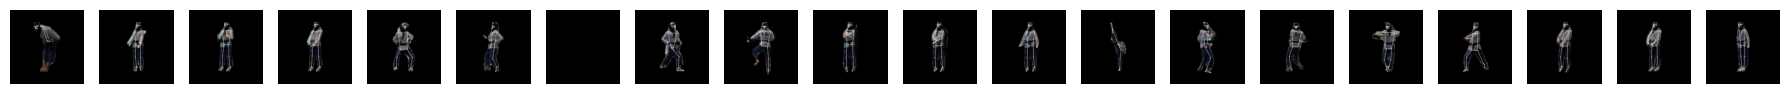

In [12]:
pose_preview_capture = cv2.VideoCapture(str(pose_overlay_path))
pose_preview_frames = []
for fraction in (0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.50, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99):

    pose_preview_capture.set(
        cv2.CAP_PROP_POS_FRAMES, round(pose_frame_count * fraction)
    )
    success, frame = pose_preview_capture.read()
    if success:
        pose_preview_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
pose_preview_capture.release()

figure, axes = plt.subplots(1, len(pose_preview_frames), figsize=(18, 5))
for axis, frame in zip(np.atleast_1d(axes), pose_preview_frames):
    axis.imshow(frame)
    axis.axis("off")
plt.tight_layout()
plt.show()

## Understand and preprocess the judge label logs

The files in `data/label/1405_05_07` are not frame-by-frame action labels. They are scoring-system audit logs for one performance each. From the sample log:

- The active panel contains five judges: `*R`, `J1`, `J2`, `J3`, and `J4`. The `J5` and `J6` columns exist in the export format but are empty.
- The timer counts down. Accuracy begins at `4.0`, and every `-0.1` or `-0.3` row is a judge deduction made at that timer value.
- `Cor` reverses a judge's most recent active deduction, so corrected deductions must not be used as training targets.
- `*A*` / `A_L` locks a judge's accuracy score. Only after this do judges enter presentation; `*P*` / `P_L` locks presentation. `U_L` is an unlock/edit event.
- The final accuracy and presentation values are calculated separately: sort the five judge scores, discard one highest and one lowest, then average the middle three.
- Accuracy deductions are useful **weak temporal labels** for the video. Presentation is only a final per-judge/per-performance score; the `P_L` time is when the score was submitted, not when a presentation mistake happened.

Because the videos will have three synchronized camera angles, all three files for a performance should share one `performance_id`. The label log is parsed once, then its event times can be mapped to frames in every view after estimating each camera's start offset. Do not assume the videos start exactly when the two-minute timer starts; verify the offset using a visible start pose, clap, flash, or another synchronization event.

In [ ]:
import re
from collections import defaultdict

LABEL_DIR = PROJECT_ROOT / "data/label/1405_05_07"
LABEL_OUTPUT_DIR = PROJECT_ROOT / "data/processed/labels/1405_05_07"
TIMER_START_SECONDS = 2 * 60

NUMBER = r"[-+]?\d+(?:\.\d+)?"
GAME_RE = re.compile(
    r"Game Number\s*:\s*(\d+).*Presentation number\s*:\s*(\d+)",
    re.IGNORECASE,
)
GROUP_RE = re.compile(
    r"Group\s*:\s*([^,]+).*Player Name\s*:\s*(.*?)\s*$",
    re.IGNORECASE,
)
GAME_SCORE_RE = re.compile(
    rf"Game Score\s*:.*Accuracy\s*=\s*({NUMBER}).*"
    rf"Presentation\s*=\s*({NUMBER}).*Negativ Score\s*=\s*({NUMBER}).*"
    rf"Total Score\s*=\s*({NUMBER})",
    re.IGNORECASE,
)
JUDGE_SCORE_RE = re.compile(
    rf"^\s*(\*?R|J\d+)\s*:\s*Accuracy\s*=\s*({NUMBER}).*"
    rf"Presentation_S&P\s*=\s*({NUMBER}).*Presentation_R&T\s*=\s*({NUMBER}).*"
    rf"Presentation_EOE\s*=\s*({NUMBER}).*Presentation\s*=\s*({NUMBER})",
    re.IGNORECASE,
)
TIME_RE = re.compile(r"^\s*(\d+)\s*:\s*(\d+)")


def clean_export_line(line):
    return line.strip().strip('"').rstrip("\r")


def parse_label_file(path, timer_start_seconds=TIMER_START_SECONDS):
    lines = [clean_export_line(line) for line in path.read_text().splitlines()]
    game_match = next((GAME_RE.search(line) for line in lines if GAME_RE.search(line)), None)
    group_match = next((GROUP_RE.search(line) for line in lines if GROUP_RE.search(line)), None)
    score_match = next(
        (GAME_SCORE_RE.search(line) for line in lines if GAME_SCORE_RE.search(line)),
        None,
    )
    if game_match is None or group_match is None or score_match is None:
        raise ValueError(f"Missing required metadata in {path.name}")

    game_number, presentation_number = map(int, game_match.groups())
    performance_id = f"M{game_number}_Per{presentation_number}"
    final_accuracy, final_presentation, negative_score, total_score = map(
        float, score_match.groups()
    )
    summary = {
        "performance_id": performance_id,
        "game_number": game_number,
        "presentation_number": presentation_number,
        "group": group_match.group(1).strip(),
        "player_name": group_match.group(2).strip(),
        "final_accuracy": final_accuracy,
        "final_presentation": final_presentation,
        "negative_score": negative_score,
        "total_score": total_score,
        "label_file": path.name,
    }

    judge_scores = []
    for line in lines:
        match = JUDGE_SCORE_RE.search(line)
        if match is None:
            continue
        judge, accuracy, speed_power, rhythm_tempo, energy, presentation = match.groups()
        judge = "*R" if judge in {"R", "*R"} else judge
        judge_scores.append(
            {
                "performance_id": performance_id,
                "judge": judge,
                "accuracy": float(accuracy),
                "presentation_speed_power": float(speed_power),
                "presentation_rhythm_tempo": float(rhythm_tempo),
                "presentation_energy": float(energy),
                "presentation": float(presentation),
            }
        )

    events = []
    for line in lines:
        time_match = TIME_RE.match(line)
        if time_match is None:
            continue
        minutes, seconds = map(int, time_match.groups())
        timer_seconds = minutes * 60 + seconds
        columns = line.split("\t")
        judge_action = columns[-1].strip() if columns else ""
        judge = judge_action.split(">")[0].strip()
        if not re.fullmatch(r"\*R|J\d+", judge):
            continue

        deduction_match = re.search(r"-0\.[13]", line)
        if deduction_match:
            event_type = "accuracy_deduction"
            deduction = abs(float(deduction_match.group()))
        elif "Cor" in line:
            event_type = "correction"
            deduction = 0.0
        elif judge_action.endswith(">A_L"):
            event_type = "accuracy_lock"
            deduction = 0.0
        elif judge_action.endswith(">P_L"):
            event_type = "presentation_lock"
            deduction = 0.0
        elif judge_action.endswith(">U_L"):
            event_type = "unlock"
            deduction = 0.0
        else:
            event_type = "other"
            deduction = 0.0

        numeric_tail = re.findall(NUMBER, "\t".join(columns[-3:-1]))
        accuracy_after = float(numeric_tail[-2]) if len(numeric_tail) >= 2 else None
        presentation_after = float(numeric_tail[-1]) if len(numeric_tail) >= 2 else None
        events.append(
            {
                "performance_id": performance_id,
                "event_id": len(events),
                "timer_seconds": timer_seconds,
                "video_seconds_unaligned": timer_start_seconds - timer_seconds,
                "judge": judge,
                "event_type": event_type,
                "deduction": deduction,
                "accuracy_after": accuracy_after,
                "presentation_after": presentation_after,
                "is_effective": event_type == "accuracy_deduction",
                "reversed_by_event_id": None,
                "raw_line": line,
            }
        )

    active_deductions = defaultdict(list)
    for event in events:
        if event["event_type"] == "accuracy_deduction":
            active_deductions[event["judge"]].append(event["event_id"])
        elif event["event_type"] == "correction" and active_deductions[event["judge"]]:
            reversed_event_id = active_deductions[event["judge"]].pop()
            events[reversed_event_id]["is_effective"] = False
            events[reversed_event_id]["reversed_by_event_id"] = event["event_id"]

    return summary, judge_scores, events


sample_label_path = sorted(LABEL_DIR.glob("*.txt"))[0]
sample_summary, sample_judge_scores, sample_events = parse_label_file(sample_label_path)
sample_summary, sample_judge_scores, sample_events[:5]

### Build clean tables and verify the scoring rule

The next cell parses every label, removes deductions canceled by `Cor`, validates the five-judge trimmed mean against the exported final score, and writes reusable CSV tables. A failed assertion is important: it means either the parser or the assumed aggregation rule needs review before training.

In [ ]:
def trimmed_mean_of_five(values):
    values = sorted(float(value) for value in values)
    if len(values) != 5:
        raise ValueError(f"Expected five judge values, received {len(values)}")
    return sum(values[1:-1]) / 3


def write_dict_rows(path, rows):
    if not rows:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as output_file:
        writer = csv.DictWriter(output_file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


game_rows = []
judge_rows = []
event_rows = []

for label_path in sorted(LABEL_DIR.glob("*.txt")):
    summary, judge_scores, events = parse_label_file(label_path)
    calculated_accuracy = trimmed_mean_of_five(
        row["accuracy"] for row in judge_scores
    )
    calculated_presentation = trimmed_mean_of_five(
        row["presentation"] for row in judge_scores
    )
    assert abs(calculated_accuracy - summary["final_accuracy"]) < 0.011
    assert abs(calculated_presentation - summary["final_presentation"]) < 0.011
    summary["calculated_accuracy"] = calculated_accuracy
    summary["calculated_presentation"] = calculated_presentation
    summary["effective_accuracy_deductions"] = sum(
        event["is_effective"] for event in events
    )
    game_rows.append(summary)
    judge_rows.extend(judge_scores)
    event_rows.extend(events)

write_dict_rows(LABEL_OUTPUT_DIR / "game_summary.csv", game_rows)
write_dict_rows(LABEL_OUTPUT_DIR / "judge_scores.csv", judge_rows)
write_dict_rows(LABEL_OUTPUT_DIR / "score_events.csv", event_rows)

print(f"Parsed {len(game_rows)} performances")
print(f"Parsed {len(judge_rows)} judge score rows")
print(f"Parsed {len(event_rows)} audit events")
print(f"Saved tables to {LABEL_OUTPUT_DIR}")


### Create conservative temporal targets

A single judge click is noisy: reaction time differs, several deductions can share one timer second, and the log does not name the technical error. A safer first target is a per-second accuracy signal. Keep both the total deduction and the number of distinct judges. Use `judge_count >= 2` as a higher-confidence consensus target, while retaining single-judge events for soft-label experiments.

Do **not** turn `accuracy_lock`, `presentation_lock`, or `unlock` rows into action labels. Presentation should initially be learned as a performance-level regression target using motion features aggregated over the whole video.

In [ ]:
per_second = defaultdict(lambda: {"judges": set(), "deduction_by_judge": defaultdict(float)})

for event in event_rows:
    if event["event_type"] != "accuracy_deduction" or not event["is_effective"]:
        continue
    key = (event["performance_id"], event["video_seconds_unaligned"])
    per_second[key]["judges"].add(event["judge"])
    per_second[key]["deduction_by_judge"][event["judge"]] += event["deduction"]

consensus_rows = []
for (performance_id, second), values in sorted(per_second.items()):
    judge_deductions = values["deduction_by_judge"].values()
    consensus_rows.append(
        {
            "performance_id": performance_id,
            "video_seconds_unaligned": second,
            "judge_count": len(values["judges"]),
            "mean_deduction_among_clicking_judges": sum(judge_deductions) / len(values["judges"]),
            "deduction_sum": sum(judge_deductions),
            "is_multi_judge_consensus": len(values["judges"]) >= 2,
        }
    )

write_dict_rows(
    LABEL_OUTPUT_DIR / "accuracy_targets_by_second.csv",
    consensus_rows,
)
print(f"Temporal target seconds: {len(consensus_rows)}")
print(
    "Multi-judge consensus seconds:",
    sum(row["is_multi_judge_consensus"] for row in consensus_rows),
)

### Map labels to the future three camera views

After adding the videos, create a manifest with one row per camera and columns such as `performance_id`, `view`, `video_path`, `fps`, and `timer_start_frame`. If frame zero is the exact `2:00` timer start, `timer_start_frame` is zero. Otherwise measure it separately for each camera. The function below converts the shared countdown time into a camera-specific frame index.

For training, use a tolerance window rather than one exact frame (for example, ±0.5 to ±1.0 seconds) because the judge presses the button after observing the error.

In [ ]:
def event_frame_index(event, fps, timer_start_frame=0, reaction_tolerance_seconds=0.75):
    center_frame = round(
        timer_start_frame + event["video_seconds_unaligned"] * fps
    )
    radius = round(reaction_tolerance_seconds * fps)
    return {
        "center_frame": center_frame,
        "window_start_frame": max(0, center_frame - radius),
        "window_end_frame": center_frame + radius,
    }


# Example only; replace these values after the three videos are added and synchronized.
example_camera_manifest = [
    {"view": "front", "fps": 30.0, "timer_start_frame": 12},
    {"view": "left", "fps": 29.97, "timer_start_frame": 8},
    {"view": "right", "fps": 30.0, "timer_start_frame": 15},
]

example_event = next(
    event for event in sample_events
    if event["event_type"] == "accuracy_deduction" and event["is_effective"]
)
{
    camera["view"]: event_frame_index(
        example_event,
        fps=camera["fps"],
        timer_start_frame=camera["timer_start_frame"],
    )
    for camera in example_camera_manifest
}

## Recommended next steps toward scoring

The scoring notes make pose estimation necessary, but not sufficient. A reliable sequence is:

1. **Validate pose and camera placement.** Measure pose coverage for front and rear views. Use at least two synchronized views when possible because a single 2D view cannot recover depth, full waist rotation, or hidden limbs reliably.
2. **Stabilize the landmark tracks.** Interpolate only short low-confidence gaps, smooth x/y trajectories, and retain a validity mask so uncertain joints never create automatic deductions.
3. **Normalize body geometry.** Express distances relative to torso length or shoulder width and define an athlete-centered coordinate system. This makes features comparable across athletes and camera distances.
4. **Build interpretable accuracy features.** Start with knee angles, stance depth, distance between ankles, wrist and ankle endpoints, limb deviation from the torso midline, trunk lean/rotation proxies, and center-of-body motion for obvious balance loss.
5. **Segment the Poomsae into techniques.** Annotate technique start/end frames and the expected ordered technique list. Compare each observed segment with its expected stance, direction, endpoint, and timing before applying the noted minor (`0.1`) or major (`0.3`) deduction.
6. **Add specialized signals.** Head/gaze direction needs face or head-pose landmarks. Wrist shape, fingers, ankle angle, and foot shape need higher-resolution hand/foot keypoints. Incorrect, added, or omitted techniques and Kihap need sequence classification plus audio.
7. **Model presentation separately.** Derive rhythm and tempo from technique durations and pauses; derive speed from landmark velocity. Treat power and energy as learned multi-modal targets rather than assuming that 2D speed alone measures them.
8. **Use the parsed judge-aligned labels.** Preserve each judge's raw score, corrected deduction events, lock events, and the five-judge aggregation: discard one highest and one lowest score and average the middle three.
9. **Calibrate label-to-video timing.** Measure the two-minute timer start separately in all three camera files and estimate judge reaction delay. Train with short temporal windows rather than assuming every click identifies an exact frame.
10. **Validate against unseen events.** Split data by athlete and competition, compare automated deductions with judge annotations, calibrate thresholds, and report agreement separately for every error type.

### Best immediate experiment

Manually label 20-30 examples of one visible criterion, such as supporting-knee bend during kicks. Calculate the knee angle from hip-knee-ankle keypoints, exclude low-confidence frames, and test whether a simple threshold separates correct and incorrect examples. This gives a small, judge-verifiable baseline before building a full scoring model.

## Train baselines from 75 labeled two-view performances

Use the labels at the level where they were created:

1. **Final accuracy and presentation scores are one label per performance.** Aggregate each complete pose sequence into one feature row per camera, concatenate the two views, and train one regression model. Do not copy a final score onto every frame; that would create thousands of fake training examples and severe leakage.
2. **Timestamped deduction logs are temporal labels.** Convert them into short positive windows around corrected, effective judge-consensus clicks. Train a separate window classifier, with every window from one performance kept in the same cross-validation fold.
3. **Raw judge scores measure label uncertainty.** Keep them for agreement analysis. Do not treat the five judge rows as five independent performances.
4. **Negative score is an external rule penalty.** Do not ask a pose-only model to learn penalties that are not visually observable. Predict accuracy and presentation, then apply known penalties when calculating the total.

With only 75 performances, start with regularized linear models and grouped cross-validation rather than a deep sequence network. These baseline models train quickly on CPU; keep the GPU for YOLO pose extraction.

### Step 1 — organize both views and create a manifest

Place each CSV at `data/processed/pose_dataset/<performance_id>/<view>/pose_keypoints.csv`. The default view names are `front` and `side`; change `REQUIRED_VIEWS` if yours differ.

`timer_start_seconds` is the timestamp inside that camera's pose CSV where the shared Poomsae timer starts. It aligns both views with `video_seconds_unaligned` in the logs. `split_group` must identify the real athlete or competition session when either repeats; this prevents the same athlete appearing in training and validation.

In [ ]:
import joblib
import pandas as pd
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

POSE_DATASET_ROOT = PROJECT_ROOT / "data/processed/pose_dataset"
TRAINING_OUTPUT_DIR = PROJECT_ROOT / "data/processed/training"
MANIFEST_PATH = TRAINING_OUTPUT_DIR / "two_view_pose_manifest.csv"
GAME_SUMMARY_PATH = LABEL_OUTPUT_DIR / "game_summary.csv"
JUDGE_SCORES_PATH = LABEL_OUTPUT_DIR / "judge_scores.csv"
TEMPORAL_TARGETS_PATH = LABEL_OUTPUT_DIR / "accuracy_targets_by_second.csv"
REQUIRED_VIEWS = ("front", "side")

TRAINING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
game_summary = pd.read_csv(GAME_SUMMARY_PATH)

if not MANIFEST_PATH.exists():
    manifest_rows = []
    for performance_id in game_summary["performance_id"]:
        for view in REQUIRED_VIEWS:
            pose_path = (
                POSE_DATASET_ROOT / performance_id / view / "pose_keypoints.csv"
            )
            manifest_rows.append(
                {
                    "performance_id": performance_id,
                    "view": view,
                    "pose_csv": str(pose_path.relative_to(PROJECT_ROOT)),
                    "timer_start_seconds": 0.0,
                    "split_group": performance_id,
                }
            )
    pd.DataFrame(manifest_rows).to_csv(MANIFEST_PATH, index=False)
    print(f"Created manifest template: {MANIFEST_PATH}")
    print("Fill timer_start_seconds and replace split_group with athlete/session IDs.")

pose_manifest = pd.read_csv(MANIFEST_PATH)
required_manifest_columns = {
    "performance_id",
    "view",
    "pose_csv",
    "timer_start_seconds",
    "split_group",
}
missing_manifest_columns = required_manifest_columns - set(pose_manifest.columns)
if missing_manifest_columns:
    raise ValueError(f"Manifest is missing columns: {sorted(missing_manifest_columns)}")

duplicate_cameras = pose_manifest.duplicated(
    ["performance_id", "view"], keep=False
)
if duplicate_cameras.any():
    raise ValueError(
        "Manifest has duplicate performance/view rows:\n"
        + pose_manifest.loc[
            duplicate_cameras, ["performance_id", "view"]
        ].to_string(index=False)
    )
group_counts = pose_manifest.groupby("performance_id")["split_group"].nunique()
if (group_counts != 1).any():
    raise ValueError("Both camera rows must use the same split_group.")

pose_manifest["pose_path"] = pose_manifest["pose_csv"].map(
    lambda value: (PROJECT_ROOT / value).resolve()
)
missing_pose_files = pose_manifest.loc[
    ~pose_manifest["pose_path"].map(Path.exists),
    ["performance_id", "view", "pose_csv"],
]
print(f"Manifest rows: {len(pose_manifest)}")
print(f"Missing pose CSV files: {len(missing_pose_files)}")
display(missing_pose_files.head(10))


### Step 2 — normalize and summarize every pose sequence

Coordinates are centered on the hips and divided by shoulder width, so camera distance and image resolution have less influence. Low-confidence joints become missing values. Each full performance is summarized with robust coordinate, confidence, and speed statistics. The two views remain separate through prefixes and are concatenated only after feature extraction.

In [ ]:
POSE_MINIMUM_CONFIDENCE = 0.25
SUMMARY_QUANTILES = (0.10, 0.50, 0.90)


def load_normalized_pose(pose_path, timer_start_seconds=0.0):
    pose = pd.read_csv(pose_path)
    required_columns = {"timestamp_seconds"}
    for joint_name in KEYPOINT_NAMES:
        required_columns.update(
            {
                f"{joint_name}_x",
                f"{joint_name}_y",
                f"{joint_name}_confidence",
            }
        )
    missing_columns = required_columns - set(pose.columns)
    if missing_columns:
        raise ValueError(f"{pose_path} is missing {sorted(missing_columns)[:5]}")

    normalized = pd.DataFrame(
        {"aligned_seconds": pose["timestamp_seconds"] - timer_start_seconds}
    )
    left_hip_valid = pose["left_hip_confidence"] >= POSE_MINIMUM_CONFIDENCE
    right_hip_valid = pose["right_hip_confidence"] >= POSE_MINIMUM_CONFIDENCE
    hip_valid = left_hip_valid & right_hip_valid
    center_x = (pose["left_hip_x"] + pose["right_hip_x"]) / 2
    center_y = (pose["left_hip_y"] + pose["right_hip_y"]) / 2
    center_x = center_x.where(hip_valid).interpolate(limit=5, limit_direction="both")
    center_y = center_y.where(hip_valid).interpolate(limit=5, limit_direction="both")

    shoulder_valid = (
        (pose["left_shoulder_confidence"] >= POSE_MINIMUM_CONFIDENCE)
        & (pose["right_shoulder_confidence"] >= POSE_MINIMUM_CONFIDENCE)
    )
    shoulder_width = np.hypot(
        pose["left_shoulder_x"] - pose["right_shoulder_x"],
        pose["left_shoulder_y"] - pose["right_shoulder_y"],
    )
    shoulder_width = pd.Series(shoulder_width).where(shoulder_valid)
    shoulder_width = shoulder_width.interpolate(limit=5, limit_direction="both")
    shoulder_width = shoulder_width.where(shoulder_width > 1e-6)

    for joint_name in KEYPOINT_NAMES:
        confidence = pose[f"{joint_name}_confidence"].astype(float)
        valid = confidence >= POSE_MINIMUM_CONFIDENCE
        normalized[f"{joint_name}_x"] = (
            (pose[f"{joint_name}_x"] - center_x) / shoulder_width
        ).where(valid)
        normalized[f"{joint_name}_y"] = (
            (pose[f"{joint_name}_y"] - center_y) / shoulder_width
        ).where(valid)
        normalized[f"{joint_name}_confidence"] = confidence
    return normalized.replace([np.inf, -np.inf], np.nan)


def summarize_pose_sequence(sequence, prefix, start_seconds=None, end_seconds=None):
    window = sequence
    if start_seconds is not None:
        window = window[window["aligned_seconds"] >= start_seconds]
    if end_seconds is not None:
        window = window[window["aligned_seconds"] <= end_seconds]
    if len(window) < 3:
        return {}

    features = {
        f"{prefix}frame_count": float(len(window)),
        f"{prefix}duration_seconds": float(
            window["aligned_seconds"].iloc[-1] - window["aligned_seconds"].iloc[0]
        ),
    }
    time_delta = window["aligned_seconds"].diff().to_numpy(dtype=float)

    for joint_name in KEYPOINT_NAMES:
        confidence = window[f"{joint_name}_confidence"]
        features[f"{prefix}{joint_name}_confidence_mean"] = float(confidence.mean())
        features[f"{prefix}{joint_name}_visible_fraction"] = float(
            (confidence >= POSE_MINIMUM_CONFIDENCE).mean()
        )

        for axis in ("x", "y"):
            values = window[f"{joint_name}_{axis}"]
            features[f"{prefix}{joint_name}_{axis}_mean"] = float(values.mean())
            features[f"{prefix}{joint_name}_{axis}_std"] = float(values.std())
            for quantile in SUMMARY_QUANTILES:
                quantile_name = round(quantile * 100)
                features[f"{prefix}{joint_name}_{axis}_q{quantile_name}"] = float(
                    values.quantile(quantile)
                )

        x_values = window[f"{joint_name}_x"].to_numpy(dtype=float)
        y_values = window[f"{joint_name}_y"].to_numpy(dtype=float)
        speed = np.hypot(np.diff(x_values), np.diff(y_values)) / time_delta[1:]
        finite_speed = speed[np.isfinite(speed)]
        features[f"{prefix}{joint_name}_speed_mean"] = (
            float(np.mean(finite_speed)) if finite_speed.size else np.nan
        )
        features[f"{prefix}{joint_name}_speed_std"] = (
            float(np.std(finite_speed)) if finite_speed.size else np.nan
        )
        features[f"{prefix}{joint_name}_speed_q90"] = (
            float(np.quantile(finite_speed, 0.90)) if finite_speed.size else np.nan
        )
    return features


### Step 3 — build one paired row per performance

A performance is included only when both required views exist. The regression targets are `final_accuracy` and `final_presentation`. `total_score` is retained only for checking the scoring equation.

In [ ]:
def build_performance_feature_table(manifest, required_views):
    feature_rows = []
    for performance_id, camera_rows in manifest.groupby("performance_id"):
        available_views = set(camera_rows["view"])
        if not set(required_views).issubset(available_views):
            continue
        if not camera_rows["pose_path"].map(Path.exists).all():
            continue

        row = {
            "performance_id": performance_id,
            "split_group": str(camera_rows["split_group"].iloc[0]),
        }
        for view in required_views:
            camera = camera_rows[camera_rows["view"] == view].iloc[0]
            sequence = load_normalized_pose(
                camera["pose_path"], camera["timer_start_seconds"]
            )
            row.update(summarize_pose_sequence(sequence, prefix=f"{view}__"))
        feature_rows.append(row)
    return pd.DataFrame(feature_rows)


performance_features = build_performance_feature_table(
    pose_manifest, REQUIRED_VIEWS
)
score_dataset = performance_features.merge(
    game_summary,
    on="performance_id",
    how="inner",
    validate="one_to_one",
)

judge_scores = pd.read_csv(JUDGE_SCORES_PATH)
judge_agreement = judge_scores.groupby("performance_id").agg(
    accuracy_judge_std=("accuracy", "std"),
    presentation_judge_std=("presentation", "std"),
).reset_index()
score_dataset = score_dataset.merge(
    judge_agreement, on="performance_id", how="left", validate="one_to_one"
)

print(f"Complete paired performances: {len(score_dataset)}")
print("Unique split groups:", score_dataset["split_group"].nunique())
display(
    score_dataset[
        [
            "performance_id",
            "split_group",
            "final_accuracy",
            "final_presentation",
            "accuracy_judge_std",
            "presentation_judge_std",
        ]
    ].head()
)


### Step 4 — grouped nested cross-validation for final scores

The outer folds estimate performance on unseen groups. The inner folds choose Ridge regularization without looking at the outer test fold. Compare against a mean-score dummy baseline. With 75 samples, out-of-fold MAE is more informative than training accuracy or a single random split.

In [ ]:
SCORE_TARGETS = ["final_accuracy", "final_presentation"]
SCORE_METADATA_COLUMNS = {
    "performance_id",
    "split_group",
    "game_number",
    "presentation_number",
    "group",
    "player_name",
    "final_accuracy",
    "final_presentation",
    "negative_score",
    "total_score",
    "label_file",
    "calculated_accuracy",
    "calculated_presentation",
    "effective_accuracy_deductions",
    "accuracy_judge_std",
    "presentation_judge_std",
}
score_feature_columns = sorted(
    column for column in score_dataset.columns if column not in SCORE_METADATA_COLUMNS
)
score_x = score_dataset[score_feature_columns]
score_y = score_dataset[SCORE_TARGETS].to_numpy(dtype=float)
score_groups = score_dataset["split_group"].astype(str).to_numpy()

unique_score_groups = np.unique(score_groups)
if len(unique_score_groups) < 3:
    raise ValueError(
        "Need at least three split groups. Update split_group with real athlete/session IDs."
    )

ridge_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge()),
    ]
)
ridge_parameters = {"ridge__alpha": np.logspace(-2, 4, 13)}
outer_score_cv = GroupKFold(n_splits=min(5, len(unique_score_groups)))
score_oof_prediction = np.full_like(score_y, np.nan)
dummy_oof_prediction = np.full_like(score_y, np.nan)

for train_indices, test_indices in outer_score_cv.split(
    score_x, score_y, groups=score_groups
):
    train_groups = score_groups[train_indices]
    inner_group_count = len(np.unique(train_groups))
    inner_score_cv = GroupKFold(n_splits=min(4, inner_group_count))
    search = GridSearchCV(
        ridge_pipeline,
        ridge_parameters,
        scoring="neg_mean_absolute_error",
        cv=inner_score_cv,
        n_jobs=-1,
    )
    search.fit(
        score_x.iloc[train_indices],
        score_y[train_indices],
        groups=train_groups,
    )
    score_oof_prediction[test_indices] = search.predict(score_x.iloc[test_indices])

    dummy = DummyRegressor(strategy="mean")
    dummy.fit(score_x.iloc[train_indices], score_y[train_indices])
    dummy_oof_prediction[test_indices] = dummy.predict(score_x.iloc[test_indices])

score_mae = mean_absolute_error(score_y, score_oof_prediction, multioutput="raw_values")
dummy_mae = mean_absolute_error(score_y, dummy_oof_prediction, multioutput="raw_values")
score_r2 = r2_score(score_y, score_oof_prediction, multioutput="raw_values")
score_metrics = pd.DataFrame(
    {
        "target": SCORE_TARGETS,
        "ridge_oof_mae": score_mae,
        "dummy_oof_mae": dummy_mae,
        "ridge_oof_r2": score_r2,
    }
)
display(score_metrics)

final_score_cv = GroupKFold(n_splits=min(5, len(unique_score_groups)))
final_score_search = GridSearchCV(
    clone(ridge_pipeline),
    ridge_parameters,
    scoring="neg_mean_absolute_error",
    cv=final_score_cv,
    n_jobs=-1,
)
final_score_search.fit(score_x, score_y, groups=score_groups)
score_model_path = TRAINING_OUTPUT_DIR / "two_view_score_ridge.joblib"
joblib.dump(
    {
        "model": final_score_search.best_estimator_,
        "feature_columns": score_feature_columns,
        "targets": SCORE_TARGETS,
        "required_views": REQUIRED_VIEWS,
    },
    score_model_path,
)
print("Best alpha:", final_score_search.best_params_["ridge__alpha"])
print(f"Saved score model: {score_model_path}")


### Step 5 — use corrected logs for temporal deduction windows

This creates overlapping two-view windows. A window is positive only near a multi-judge consensus deduction. Windows near a single-judge click are excluded rather than marked negative. The model therefore learns **probability of a consensus accuracy deduction**, not a named technical error. To learn specific errors such as wrong stance or balance loss, add an `error_type` annotation to the event windows.

In [ ]:
WINDOW_RADIUS_SECONDS = 1.0
WINDOW_HOP_SECONDS = 0.5
POSITIVE_TOLERANCE_SECONDS = 0.75
AMBIGUOUS_EVENT_BUFFER_SECONDS = 2.0


def build_temporal_feature_table(manifest, required_views, temporal_targets):
    rows = []
    for performance_id, camera_rows in manifest.groupby("performance_id"):
        if not set(required_views).issubset(set(camera_rows["view"])):
            continue
        if not camera_rows["pose_path"].map(Path.exists).all():
            continue

        sequences = {}
        for view in required_views:
            camera = camera_rows[camera_rows["view"] == view].iloc[0]
            sequences[view] = load_normalized_pose(
                camera["pose_path"], camera["timer_start_seconds"]
            )
        common_start = max(
            sequence["aligned_seconds"].min() for sequence in sequences.values()
        )
        common_end = min(
            sequence["aligned_seconds"].max() for sequence in sequences.values()
        )
        if common_end - common_start < 2 * WINDOW_RADIUS_SECONDS:
            continue

        performance_targets = temporal_targets[
            temporal_targets["performance_id"] == performance_id
        ]
        all_event_times = performance_targets["video_seconds_unaligned"].to_numpy(
            dtype=float
        )
        consensus_event_times = performance_targets.loc[
            performance_targets["judge_count"] >= 2,
            "video_seconds_unaligned",
        ].to_numpy(dtype=float)

        centers = np.arange(
            common_start + WINDOW_RADIUS_SECONDS,
            common_end - WINDOW_RADIUS_SECONDS + 1e-9,
            WINDOW_HOP_SECONDS,
        )
        for center_seconds in centers:
            consensus_distance = (
                np.min(np.abs(consensus_event_times - center_seconds))
                if consensus_event_times.size
                else np.inf
            )
            any_event_distance = (
                np.min(np.abs(all_event_times - center_seconds))
                if all_event_times.size
                else np.inf
            )
            if consensus_distance <= POSITIVE_TOLERANCE_SECONDS:
                deduction_label = 1
            elif any_event_distance < AMBIGUOUS_EVENT_BUFFER_SECONDS:
                continue
            else:
                deduction_label = 0

            row = {
                "performance_id": performance_id,
                "window_center_seconds": float(center_seconds),
                "deduction_label": deduction_label,
            }
            for view, sequence in sequences.items():
                row.update(
                    summarize_pose_sequence(
                        sequence,
                        prefix=f"{view}__",
                        start_seconds=center_seconds - WINDOW_RADIUS_SECONDS,
                        end_seconds=center_seconds + WINDOW_RADIUS_SECONDS,
                    )
                )
            rows.append(row)
    return pd.DataFrame(rows)


temporal_targets = pd.read_csv(TEMPORAL_TARGETS_PATH)
temporal_dataset = build_temporal_feature_table(
    pose_manifest, REQUIRED_VIEWS, temporal_targets
)
print(f"Temporal windows: {len(temporal_dataset)}")
print("Positive windows:", int(temporal_dataset["deduction_label"].sum()))
print("Performances:", temporal_dataset["performance_id"].nunique())


### Step 6 — grouped temporal classification

All windows from one performance stay together through `StratifiedGroupKFold`. Average precision is the primary metric because positive deductions are rare. Precision answers how many alerts are correct; recall answers how many consensus deductions are found.

In [ ]:
TEMPORAL_METADATA_COLUMNS = {
    "performance_id",
    "window_center_seconds",
    "deduction_label",
}
temporal_feature_columns = sorted(
    column
    for column in temporal_dataset.columns
    if column not in TEMPORAL_METADATA_COLUMNS
)
temporal_x = temporal_dataset[temporal_feature_columns]
temporal_y = temporal_dataset["deduction_label"].to_numpy(dtype=int)
temporal_groups = temporal_dataset["performance_id"].astype(str).to_numpy()

if len(np.unique(temporal_y)) < 2:
    raise ValueError("Temporal data needs both positive and negative windows.")
if len(np.unique(temporal_groups)) < 3:
    raise ValueError("Temporal data needs at least three performances.")

temporal_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                solver="liblinear",
            ),
        ),
    ]
)
temporal_parameters = {"classifier__C": np.logspace(-3, 2, 8)}
temporal_group_count = len(np.unique(temporal_groups))
outer_temporal_cv = StratifiedGroupKFold(
    n_splits=min(5, temporal_group_count), shuffle=True, random_state=42
)
temporal_oof_probability = np.full(len(temporal_y), np.nan)

for train_indices, test_indices in outer_temporal_cv.split(
    temporal_x, temporal_y, groups=temporal_groups
):
    train_groups = temporal_groups[train_indices]
    inner_group_count = len(np.unique(train_groups))
    inner_temporal_cv = StratifiedGroupKFold(
        n_splits=min(4, inner_group_count), shuffle=True, random_state=43
    )
    search = GridSearchCV(
        temporal_pipeline,
        temporal_parameters,
        scoring="average_precision",
        cv=inner_temporal_cv,
        n_jobs=-1,
    )
    search.fit(
        temporal_x.iloc[train_indices],
        temporal_y[train_indices],
        groups=train_groups,
    )
    temporal_oof_probability[test_indices] = search.predict_proba(
        temporal_x.iloc[test_indices]
    )[:, 1]

temporal_oof_prediction = (temporal_oof_probability >= 0.5).astype(int)
temporal_metrics = {
    "positive_prevalence": float(np.mean(temporal_y)),
    "oof_average_precision": average_precision_score(
        temporal_y, temporal_oof_probability
    ),
    "oof_precision_at_0.5": precision_score(
        temporal_y, temporal_oof_prediction, zero_division=0
    ),
    "oof_recall_at_0.5": recall_score(
        temporal_y, temporal_oof_prediction, zero_division=0
    ),
    "oof_f1_at_0.5": f1_score(
        temporal_y, temporal_oof_prediction, zero_division=0
    ),
}
display(pd.Series(temporal_metrics, name="value"))

final_temporal_cv = StratifiedGroupKFold(
    n_splits=min(5, temporal_group_count), shuffle=True, random_state=44
)
final_temporal_search = GridSearchCV(
    clone(temporal_pipeline),
    temporal_parameters,
    scoring="average_precision",
    cv=final_temporal_cv,
    n_jobs=-1,
)
final_temporal_search.fit(
    temporal_x, temporal_y, groups=temporal_groups
)
temporal_model_path = TRAINING_OUTPUT_DIR / "two_view_deduction_logistic.joblib"
joblib.dump(
    {
        "model": final_temporal_search.best_estimator_,
        "feature_columns": temporal_feature_columns,
        "required_views": REQUIRED_VIEWS,
        "window_radius_seconds": WINDOW_RADIUS_SECONDS,
        "positive_tolerance_seconds": POSITIVE_TOLERANCE_SECONDS,
    },
    temporal_model_path,
)
print("Best C:", final_temporal_search.best_params_["classifier__C"])
print(f"Saved temporal model: {temporal_model_path}")


### Step 7 — decide whether the baselines are useful

- The score model must beat `dummy_oof_mae`. A negative out-of-fold R² means the current pose summaries are not yet predictive enough.
- Compare MAE with judge disagreement. If model error is close to inter-judge variation, labels may be the limiting factor.
- Temporal average precision must be clearly above `positive_prevalence`; otherwise it is not better than ranking windows randomly.
- Never report metrics from the final fitted model on its training rows. Keep the out-of-fold predictions as the honest estimate.
- For the next improvement, annotate technique boundaries and error types. The current final-score target is too coarse to teach the model exactly which stance, block, kick, or timing error occurred.